Using refs: ['00000000', '00001000', '00010000']
SR dim: 5 MR dim: 15
Exact full-matrix ground energy: -27.754205
SR Ritz E0: -11.721592 | MR Ritz E0: -14.920963 | Exact: -27.754205


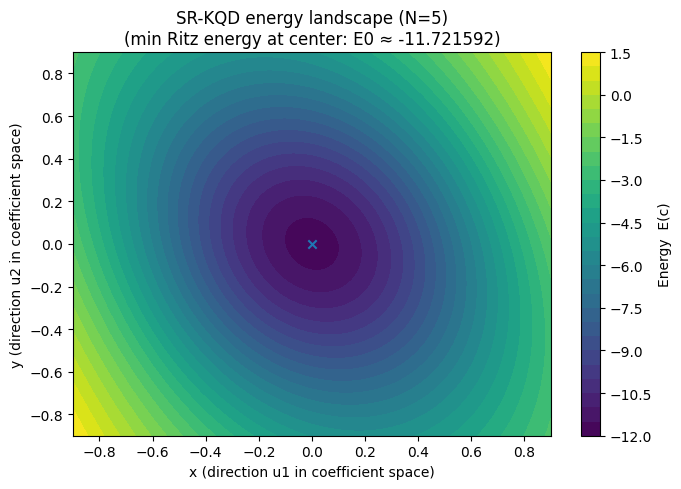

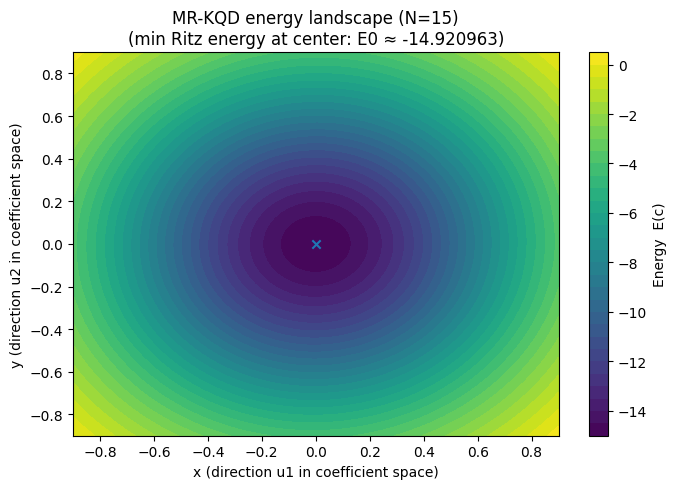

'\nUncomment to generate an animation that rotates the plane directions (u1,u2)\naround the optimum and shows how the local landscape changes.\n\nRequires: matplotlib.animation\n'

In [1]:
"""
Visual “energy landscape” for SR-KQD vs MR-KQD on your XX/YY/ZZ chain Hamiltonian.

What you get:
1) Exact Hamiltonian matrix H (2^n x 2^n) from your Pauli-string construction
2) Exact Krylov bases (no sampling): |psi_{I,n}> = U^n |Phi_I>, with U = exp(-i dt H)
3) Subspace matrices S and H_sub
4) Energy landscape on a 2D slice around the optimal Ritz vector:
      E(c) = (c† H_sub c) / (c† S c)
   plotted as a contour map for SR (dim=5) and MR (dim=15).

Requires: numpy, scipy, matplotlib, qiskit (for SparsePauliOp only)
"""

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp

# -----------------------------
# 0) User parameters
# -----------------------------
n_qubits = 8          # <= 10 is fine locally; 8 is fast and still illustrative
JX, JY, JZ = 1.0, 3.0, 2.0

krylov_dim = 5        # s+1
s = krylov_dim - 1
d_refs = 3            # multireference count

# pick references similar to your notebook
excitation_sys = n_qubits // 2
ref_bitstrings = [
    "0" * n_qubits,  # optional vacuum
    "0" * excitation_sys + "1" + "0" * (n_qubits - excitation_sys - 1),
    "0" * max(excitation_sys - 1, 0) + "1" + "0" * (n_qubits - max(excitation_sys - 1, 0) - 1),
][:d_refs]

print("Using refs:", ref_bitstrings)
print("SR dim:", krylov_dim, "MR dim:", d_refs * krylov_dim)

# -----------------------------
# 1) Build Hamiltonian (your construction)
# -----------------------------
H_int = [["I"] * n_qubits for _ in range(3 * (n_qubits - 1))]

for i in range(n_qubits - 1):
    H_int[i][i] = "Z"
    H_int[i][i + 1] = "Z"

for i in range(n_qubits - 1):
    H_int[n_qubits - 1 + i][i] = "X"
    H_int[n_qubits - 1 + i][i + 1] = "X"

for i in range(n_qubits - 1):
    H_int[2 * (n_qubits - 1) + i][i] = "Y"
    H_int[2 * (n_qubits - 1) + i][i + 1] = "Y"

H_int = ["".join(term) for term in H_int]
H_tot = [
    (term, JZ) if term.count("Z") == 2 else
    (term, JY) if term.count("Y") == 2 else
    (term, JX)
    for term in H_int
]

H_op = SparsePauliOp.from_list(H_tot)

# Build dense matrix H (2^n x 2^n)
H = H_op.to_matrix().astype(complex)
dim = H.shape[0]

# -----------------------------
# 2) Choose dt and build U = exp(-i dt H)
# -----------------------------
# A conservative dt: pi / ||H||_2 (spectral norm)
H_norm = la.norm(H, 2)
dt = np.pi / H_norm
U = la.expm(-1j * dt * H)

# -----------------------------
# 3) Helpers: basis states, Krylov basis, subspace matrices
# -----------------------------
def basis_state_from_bitstring(bs: str) -> np.ndarray:
    """Computational basis ket |bs> (big-endian in the string)."""
    idx = int(bs, 2)
    v = np.zeros((dim,), dtype=complex)
    v[idx] = 1.0
    return v

def build_krylov_chain(phi: np.ndarray, krylov_dim: int) -> list[np.ndarray]:
    """Return [phi, U phi, U^2 phi, ...]"""
    chain = [phi]
    cur = phi
    for _ in range(1, krylov_dim):
        cur = U @ cur
        chain.append(cur)
    return chain

def subspace_matrices(psi_list: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    """
    Given basis vectors { |psi_a> }, build:
      S_ab = <psi_a|psi_b>
      H_ab = <psi_a| H |psi_b>
    """
    N = len(psi_list)
    S = np.zeros((N, N), dtype=complex)
    Hsub = np.zeros((N, N), dtype=complex)
    for a in range(N):
        bra = np.conjugate(psi_list[a])
        for b in range(N):
            ket = psi_list[b]
            S[a, b] = bra @ ket
            Hsub[a, b] = bra @ (H @ ket)
    # Hermitize for numerical cleanliness
    S = (S + S.conj().T) / 2
    Hsub = (Hsub + Hsub.conj().T) / 2
    return S, Hsub

def ritz_ground(S: np.ndarray, Hsub: np.ndarray, eps: float = 1e-10) -> tuple[float, np.ndarray]:
    """
    Solve generalized eigenproblem H c = S c E robustly by
    projecting out tiny eigenvalues of S.
    """
    # Eigen-decomp S
    w, V = la.eigh(S)
    keep = w > eps
    if not np.any(keep):
        raise RuntimeError("S is numerically singular; increase eps or change refs/dt.")
    Wm12 = np.diag(1.0 / np.sqrt(w[keep]))
    Vk = V[:, keep]
    # Transform to standard eigenproblem
    A = Wm12 @ (Vk.conj().T @ Hsub @ Vk) @ Wm12
    evals, evecs = la.eigh(A)
    E0 = float(evals[0].real)
    # Back-transform eigenvector
    c0 = Vk @ (Wm12 @ evecs[:, 0])
    # normalize in S metric: c† S c = 1
    norm = np.sqrt(np.conjugate(c0) @ (S @ c0))
    c0 = c0 / norm
    return E0, c0

def energy_rayleigh(c: np.ndarray, S: np.ndarray, Hsub: np.ndarray) -> float:
    num = np.conjugate(c) @ (Hsub @ c)
    den = np.conjugate(c) @ (S @ c)
    return float((num / den).real)

def orthonormal_plane_around(c0: np.ndarray, S: np.ndarray, seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Build two S-orthonormal directions u1,u2 that are S-orthogonal to c0:
      c0† S u = 0,  u† S u = 1
    """
    rng = np.random.default_rng(seed)
    N = len(c0)

    def proj_out(v):
        # remove component along c0 in S-inner-product
        alpha = (np.conjugate(c0) @ (S @ v))
        v2 = v - alpha * c0
        return v2

    def normalize_S(v):
        nv = np.sqrt(np.conjugate(v) @ (S @ v))
        return v / nv

    # u1
    v1 = rng.normal(size=N) + 1j * rng.normal(size=N)
    v1 = proj_out(v1)
    u1 = normalize_S(v1)

    # u2
    v2 = rng.normal(size=N) + 1j * rng.normal(size=N)
    v2 = proj_out(v2)
    # also remove component along u1
    beta = (np.conjugate(u1) @ (S @ v2))
    v2 = v2 - beta * u1
    u2 = normalize_S(v2)

    return u1, u2

def make_landscape(S: np.ndarray, Hsub: np.ndarray, title: str, amplitude: float = 0.7, grid: int = 121, seed: int = 0):
    """
    Plot E(x,y) for c(x,y) = normalize_S(c0 + x u1 + y u2),
    with x,y in [-amplitude, amplitude].
    """
    E0, c0 = ritz_ground(S, Hsub)
    u1, u2 = orthonormal_plane_around(c0, S, seed=seed)

    xs = np.linspace(-amplitude, amplitude, grid)
    ys = np.linspace(-amplitude, amplitude, grid)
    Z = np.zeros((grid, grid), dtype=float)

    for i, x in enumerate(xs):
        for j, y in enumerate(ys):
            c = c0 + x * u1 + y * u2
            # normalize in S-metric
            c = c / np.sqrt(np.conjugate(c) @ (S @ c))
            Z[j, i] = energy_rayleigh(c, S, Hsub)

    # plot
    plt.figure(figsize=(7, 5))
    X, Y = np.meshgrid(xs, ys)
    cs = plt.contourf(X, Y, Z, levels=30)
    plt.colorbar(cs, label="Energy  E(c)")
    # mark optimum at (0,0)
    plt.scatter([0], [0], marker="x")
    plt.title(f"{title}\n(min Ritz energy at center: E0 ≈ {E0:.6f})")
    plt.xlabel("x (direction u1 in coefficient space)")
    plt.ylabel("y (direction u2 in coefficient space)")
    plt.tight_layout()

    return E0

# -----------------------------
# 4) Build SR and MR Krylov bases
# -----------------------------
# SR: single reference (use one excitation like your SR example)
sr_ref = ref_bitstrings[1] if len(ref_bitstrings) > 1 else ref_bitstrings[0]
phi_sr = basis_state_from_bitstring(sr_ref)
psi_sr = build_krylov_chain(phi_sr, krylov_dim)
S_sr, H_sr = subspace_matrices(psi_sr)

# MR: d reference states, each with its Krylov chain, concatenated
psi_mr = []
for bs in ref_bitstrings:
    phi = basis_state_from_bitstring(bs)
    psi_mr.extend(build_krylov_chain(phi, krylov_dim))
S_mr, H_mr = subspace_matrices(psi_mr)

# Exact ground energy (full diagonalization) for reference
evals_full = la.eigvalsh(H)
E_exact = float(evals_full[0].real)
print(f"Exact full-matrix ground energy: {E_exact:.6f}")

# -----------------------------
# 5) Plot landscapes: SR vs MR
# -----------------------------
E0_sr = make_landscape(S_sr, H_sr, title=f"SR-KQD energy landscape (N={krylov_dim})", amplitude=0.9, grid=121, seed=1)
E0_mr = make_landscape(S_mr, H_mr, title=f"MR-KQD energy landscape (N={d_refs*krylov_dim})", amplitude=0.9, grid=121, seed=2)

# Print summary
print(f"SR Ritz E0: {E0_sr:.6f} | MR Ritz E0: {E0_mr:.6f} | Exact: {E_exact:.6f}")

plt.show()

# -----------------------------
# OPTIONAL: simple animation (rotate the 2D slice plane)
# -----------------------------
"""
Uncomment to generate an animation that rotates the plane directions (u1,u2)
around the optimum and shows how the local landscape changes.

Requires: matplotlib.animation
"""

# from matplotlib.animation import FuncAnimation
# import matplotlib.animation as animation
#
# def animate_landscape(S, Hsub, title, amplitude=0.9, grid=81, seed=0, frames=60):
#     E0, c0 = ritz_ground(S, Hsub)
#     u1, u2 = orthonormal_plane_around(c0, S, seed=seed)
#     xs = np.linspace(-amplitude, amplitude, grid)
#     ys = np.linspace(-amplitude, amplitude, grid)
#     X, Y = np.meshgrid(xs, ys)
#
#     fig, ax = plt.subplots(figsize=(7, 5))
#     Z = np.zeros((grid, grid), dtype=float)
#     cf = ax.contourf(X, Y, Z, levels=30)
#     cbar = fig.colorbar(cf, ax=ax, label="Energy  E(c)")
#     ax.scatter([0], [0], marker="x")
#     ax.set_title(f"{title} (E0≈{E0:.6f})")
#     ax.set_xlabel("x")
#     ax.set_ylabel("y")
#
#     def update(frame):
#         nonlocal cf
#         angle = 2*np.pi*frame/frames
#         v1 = np.cos(angle)*u1 + np.sin(angle)*u2
#         v2 = -np.sin(angle)*u1 + np.cos(angle)*u2
#
#         for i, x in enumerate(xs):
#             for j, y in enumerate(ys):
#                 c = c0 + x*v1 + y*v2
#                 c = c / np.sqrt(np.conjugate(c) @ (S @ c))
#                 Z[j, i] = energy_rayleigh(c, S, Hsub)
#
#         for coll in cf.collections:
#             coll.remove()
#         cf = ax.contourf(X, Y, Z, levels=30)
#         return cf.collections
#
#     ani = FuncAnimation(fig, update, frames=frames, blit=False)
#     plt.show()
#     return ani
#
# # Example:
# # ani_sr = animate_landscape(S_sr, H_sr, "SR-KQD rotating slice", seed=3)
# # ani_mr = animate_landscape(S_mr, H_mr, "MR-KQD rotating slice", seed=4)
# # To save (optional): ani_sr.save("sr_landscape.gif", writer="pillow", fps=15)


Exact ground energy: -27.754204517325572
MR refs: ['00000000', '00001000', '00010000']
SR energy range: -3.790796094139366 15.054574220932523
MR energy range: 0.11608048358478529 14.903952599401265


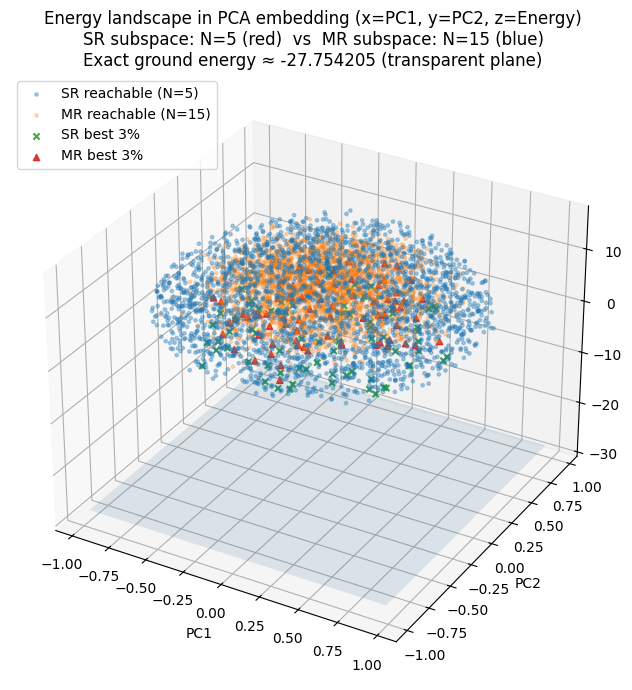

In [2]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from qiskit.quantum_info import SparsePauliOp

# =========================
# 0) Parameters
# =========================
n_qubits = 8          # try 6..9 for fast local runs (2^9=512 OK)
JX, JY, JZ = 1.0, 3.0, 2.0

krylov_dim = 5        # s+1
d_refs = 3            # number of reference states in MR

N_sr = krylov_dim
N_mr = d_refs * krylov_dim

# sampling density (increase if you want smoother “clouds”)
n_samples_sr = 2500
n_samples_mr = 2500

rng = np.random.default_rng(0)

# =========================
# 1) Build Hamiltonian (your code)
# =========================
H_int = [["I"] * n_qubits for _ in range(3 * (n_qubits - 1))]
for i in range(n_qubits - 1):
    H_int[i][i] = "Z"
    H_int[i][i + 1] = "Z"
for i in range(n_qubits - 1):
    H_int[n_qubits - 1 + i][i] = "X"
    H_int[n_qubits - 1 + i][i + 1] = "X"
for i in range(n_qubits - 1):
    H_int[2 * (n_qubits - 1) + i][i] = "Y"
    H_int[2 * (n_qubits - 1) + i][i + 1] = "Y"

H_int = ["".join(term) for term in H_int]
H_tot = [
    (term, JZ) if term.count("Z") == 2 else
    (term, JY) if term.count("Y") == 2 else
    (term, JX)
    for term in H_int
]

H_op = SparsePauliOp.from_list(H_tot)
H = H_op.to_matrix().astype(complex)
dim = H.shape[0]

# Exact ground energy (for reference)
E_exact = float(np.min(la.eigvalsh(H)).real)
print("Exact ground energy:", E_exact)

# =========================
# 2) Choose dt and unitary U = exp(-i dt H)
# =========================
dt = np.pi / la.norm(H, 2)
U = la.expm(-1j * dt * H)

# =========================
# 3) References and Krylov bases
# =========================
def basis_state_from_bitstring(bs: str) -> np.ndarray:
    idx = int(bs, 2)
    v = np.zeros((dim,), dtype=complex)
    v[idx] = 1.0
    return v

def build_krylov_chain(phi: np.ndarray, K: int) -> list[np.ndarray]:
    chain = [phi]
    cur = phi
    for _ in range(1, K):
        cur = U @ cur
        chain.append(cur)
    return chain

# references similar to your notebook
excitation_sys = n_qubits // 2
ref_bitstrings = [
    "0" * n_qubits,
    "0" * excitation_sys + "1" + "0" * (n_qubits - excitation_sys - 1),
    "0" * max(excitation_sys - 1, 0) + "1" + "0" * (n_qubits - max(excitation_sys - 1, 0) - 1),
][:d_refs]

print("MR refs:", ref_bitstrings)

# SR basis: pick the single-excitation ref (like your SR)
sr_ref = ref_bitstrings[1] if len(ref_bitstrings) > 1 else ref_bitstrings[0]
psi_sr = build_krylov_chain(basis_state_from_bitstring(sr_ref), krylov_dim)

# MR basis: concatenate chains from each reference
psi_mr = []
for bs in ref_bitstrings:
    psi_mr.extend(build_krylov_chain(basis_state_from_bitstring(bs), krylov_dim))

# Stack into matrices B whose columns are basis vectors |psi_a>
B_sr = np.column_stack(psi_sr)  # shape (dim, N_sr)
B_mr = np.column_stack(psi_mr)  # shape (dim, N_mr)

# =========================
# 4) Sample random representable states and compute energies
# =========================
def sample_coeffs(n_samples: int, N: int) -> np.ndarray:
    # random complex coefficients
    c = rng.normal(size=(n_samples, N)) + 1j * rng.normal(size=(n_samples, N))
    # normalize Euclidean coeff norm (not S-metric; we normalize the physical state later)
    c /= np.linalg.norm(c, axis=1, keepdims=True)
    return c

def states_and_energies(B: np.ndarray, n_samples: int):
    C = sample_coeffs(n_samples, B.shape[1])               # (n_samples, N)
    Psi = (B @ C.T).T                                      # (n_samples, dim)
    # normalize physical states
    norms = np.sqrt(np.sum(np.abs(Psi)**2, axis=1, keepdims=True))
    Psi = Psi / norms

    # energies: <Psi|H|Psi>
    HPsi = (H @ Psi.T).T
    E = np.einsum("bi,bi->b", np.conjugate(Psi), HPsi).real
    return Psi, E

Psi_sr, E_sr = states_and_energies(B_sr, n_samples_sr)
Psi_mr, E_mr = states_and_energies(B_mr, n_samples_mr)

print("SR energy range:", float(E_sr.min()), float(E_sr.max()))
print("MR energy range:", float(E_mr.min()), float(E_mr.max()))

# =========================
# 5) PCA embedding of physical states (SR+MR together)
#    We'll embed complex state vectors into R^(2*dim) by concatenating Re/Im.
# =========================
X = np.vstack([Psi_sr, Psi_mr])                 # (n_total, dim)
Xr = np.hstack([X.real, X.imag])                # (n_total, 2*dim)
Xr -= Xr.mean(axis=0, keepdims=True)

# PCA via SVD
U_svd, S_svd, Vt = np.linalg.svd(Xr, full_matrices=False)
PC = Xr @ Vt[:2].T                               # (n_total, 2)

pc_sr = PC[:len(Psi_sr)]
pc_mr = PC[len(Psi_sr):]

# =========================
# 6) 3D plot: reachable regions SR (red) vs MR (blue)
# =========================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Scatter clouds
ax.scatter(pc_sr[:, 0], pc_sr[:, 1], E_sr, s=6, alpha=0.35, label="SR reachable (N=5)")
ax.scatter(pc_mr[:, 0], pc_mr[:, 1], E_mr, s=6, alpha=0.25, label="MR reachable (N=15)")

# Highlight “low-energy frontier” (best few %)
def highlight_frontier(pc, E, frac=0.03, marker="o", label=""):
    k = max(10, int(frac * len(E)))
    idx = np.argsort(E)[:k]
    ax.scatter(pc[idx, 0], pc[idx, 1], E[idx], s=20, alpha=0.9, marker=marker, label=label)

highlight_frontier(pc_sr, E_sr, frac=0.03, marker="x", label="SR best 3%")
highlight_frontier(pc_mr, E_mr, frac=0.03, marker="^", label="MR best 3%")

# Exact ground energy plane
xx = np.linspace(min(PC[:, 0]), max(PC[:, 0]), 10)
yy = np.linspace(min(PC[:, 1]), max(PC[:, 1]), 10)
XX, YY = np.meshgrid(xx, yy)
ZZ = E_exact * np.ones_like(XX)
ax.plot_surface(XX, YY, ZZ, alpha=0.12)

ax.set_title(
    f"Energy landscape in PCA embedding (x=PC1, y=PC2, z=Energy)\n"
    f"SR subspace: N={N_sr} (red)  vs  MR subspace: N={N_mr} (blue)\n"
    f"Exact ground energy ≈ {E_exact:.6f} (transparent plane)"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("Energy")

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


Exact ground energy: -27.754204517325572
SR ref: 00001000
MR refs: ['00000000', '00001000', '10101010']
Saved GIF: sr_vs_mr_energy_landscape_7s33.gif


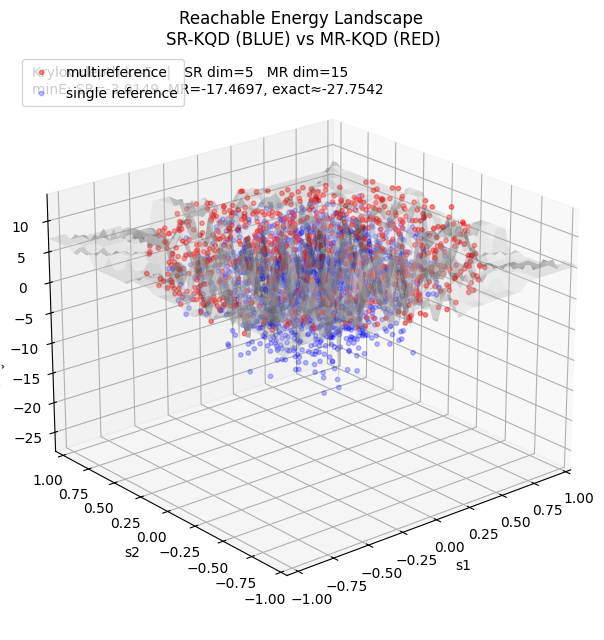

In [7]:
# Copy-paste script that GENERATES the GIF locally.
# - ONE shared 3D coordinate system
# - Gray surface = energy landscape (bounded, built from a convex-hull-safe interpolation)
# - SR scatter = RED, MR scatter = BLUE
# - Slower camera rotation
# - Ensures scatters stay inside the surface bounds (surface bounds derived from both scatters)
#
# Dependencies: numpy, scipy, matplotlib
# Optional: pillow (for GIF saving). If missing, it will save MP4 if ffmpeg is available.

import numpy as np
import scipy.linalg as la
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================
# 0) Settings you can tweak
# =========================
n_qubits = 8        # 6..9 recommended; 8 gives visible structure but still feasible
JX, JY, JZ = 1.0, 3.0, 2.0

krylov_dim_max = 5  # as requested
d_refs = 3          # MR references

# Use more MR points than SR so MR "wider" is visually obvious.
n_samples_sr = 800
n_samples_mr = 1800

# Animation settings
FPS = 20
DURATION_S = 7
FRAMES = FPS * DURATION_S

# Slower rotation: total azimuth sweep over whole clip
AZIM_SWEEP_DEG = 200   # smaller = slower
ELEV_BASE = 22
ELEV_WOBBLE = 3

SR_COLOR = "red"
MR_COLOR = "blue"

# Landscape grid resolution (keep moderate for speed)
GRID_N = 55

# How k evolves through the clip: first part ramps 1->5, then holds at 5
RAMP_FRACTION = 0.70

rng = np.random.default_rng(0)

# =========================
# 1) Build your Hamiltonian dense matrix H
# =========================
I2 = np.array([[1, 0], [0, 1]], dtype=complex)
X2 = np.array([[0, 1], [1, 0]], dtype=complex)
Y2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X2, "Y": Y2, "Z": Z2}

def kron_all(ops):
    M = ops[0]
    for op in ops[1:]:
        M = np.kron(M, op)
    return M

dim = 2 ** n_qubits
H = np.zeros((dim, dim), dtype=complex)

for i in range(n_qubits - 1):
    for p, J in [("X", JX), ("Y", JY), ("Z", JZ)]:
        ops = ["I"] * n_qubits
        ops[i] = p
        ops[i + 1] = p
        H += J * kron_all([PAULI[o] for o in ops])

E_exact = float(np.min(la.eigvalsh(H)).real)
print("Exact ground energy:", E_exact)

# =========================
# 2) Time evolution U = exp(-i dt H)
# =========================
dt = np.pi / la.norm(H, 2)
U = la.expm(-1j * dt * H)

# =========================
# 3) References & Krylov bases
# =========================
def basis_state_from_bitstring(bs):
    v = np.zeros((dim,), dtype=complex)
    v[int(bs, 2)] = 1.0
    return v

def build_krylov_chain(phi, K):
    chain = [phi]
    cur = phi
    for _ in range(1, K):
        cur = U @ cur
        chain.append(cur)
    return chain

# Use three references; for better visual separation, make them "more different"
# than just neighboring single excitations. These are still easy computational basis refs.
# - vacuum
# - single excitation center
# - Néel-like pattern (alternating)
excitation_sys = n_qubits // 2
ref_bitstrings = [
    "0" * n_qubits,
    "0" * excitation_sys + "1" + "0" * (n_qubits - excitation_sys - 1),
    "".join("1" if (i % 2 == 0) else "0" for i in range(n_qubits)),
][:d_refs]

sr_ref = ref_bitstrings[1]  # keep SR as single-excitation like your notebook
print("SR ref:", sr_ref)
print("MR refs:", ref_bitstrings)

psi_sr_full = build_krylov_chain(basis_state_from_bitstring(sr_ref), krylov_dim_max)
B_sr_full = np.column_stack(psi_sr_full)  # (dim, 5)

psi_mr_full = []
for bs in ref_bitstrings:
    psi_mr_full.extend(build_krylov_chain(basis_state_from_bitstring(bs), krylov_dim_max))
B_mr_full = np.column_stack(psi_mr_full)  # (dim, 15)

# =========================
# 4) Sampling reachable states and energies
# =========================
def sample_coeffs(n_samples, N):
    c = rng.normal(size=(n_samples, N)) + 1j * rng.normal(size=(n_samples, N))
    c /= np.linalg.norm(c, axis=1, keepdims=True)
    return c

def states_and_energies(B, n_samples):
    C = sample_coeffs(n_samples, B.shape[1])
    Psi = (B @ C.T).T
    Psi /= np.sqrt(np.sum(np.abs(Psi) ** 2, axis=1, keepdims=True))
    HPsi = (H @ Psi.T).T
    E = np.einsum("bi,bi->b", np.conjugate(Psi), HPsi).real
    return Psi, E

# =========================
# 5) Fixed PCA axes (built from max-k SR+MR) for a shared coordinate system
# =========================
Psi_sr0, _ = states_and_energies(B_sr_full, min(2000, n_samples_sr))
Psi_mr0, _ = states_and_energies(B_mr_full, min(2000, n_samples_mr))
X = np.vstack([Psi_sr0, Psi_mr0])
Xr = np.hstack([X.real, X.imag])
Xr -= Xr.mean(axis=0, keepdims=True)

_, _, Vt = la.svd(Xr, full_matrices=False)
PCA2 = Vt[:2].T

def embed_pca2(Psi):
    Z = np.hstack([Psi.real, Psi.imag])
    Z -= Z.mean(axis=0, keepdims=True)
    return Z @ PCA2

# =========================
# 6) Precompute clouds for each k so animation never "empties"
# =========================
clouds_sr, clouds_mr = [], []
for k in range(1, krylov_dim_max + 1):
    # SR basis: first k columns
    B_sr_k = B_sr_full[:, :k]
    Psi_sr_k, E_sr_k = states_and_energies(B_sr_k, n_samples_sr)
    pc_sr_k = embed_pca2(Psi_sr_k)
    clouds_sr.append((pc_sr_k, E_sr_k))

    # MR basis: first k per reference block
    cols = []
    for I in range(d_refs):
        start = I * krylov_dim_max
        cols.extend(range(start, start + k))
    B_mr_k = B_mr_full[:, cols]
    Psi_mr_k, E_mr_k = states_and_energies(B_mr_k, n_samples_mr)
    pc_mr_k = embed_pca2(Psi_mr_k)
    clouds_mr.append((pc_mr_k, E_mr_k))

# =========================
# 7) Build a bounded gray energy surface that CONTAINS both scatters
# =========================
# Use max-k clouds as the domain definition
PC_all = np.vstack([clouds_sr[-1][0], clouds_mr[-1][0]])
E_all = np.concatenate([clouds_sr[-1][1], clouds_mr[-1][1]])

# Domain bounds: a bit wider than the min/max to ensure all points fit.
pad = 0.05
xmin = np.min(PC_all[:, 0]) - pad * (np.ptp(PC_all[:, 0]) + 1e-12)
xmax = np.max(PC_all[:, 0]) + pad * (np.ptp(PC_all[:, 0]) + 1e-12)
ymin = np.min(PC_all[:, 1]) - pad * (np.ptp(PC_all[:, 1]) + 1e-12)
ymax = np.max(PC_all[:, 1]) + pad * (np.ptp(PC_all[:, 1]) + 1e-12)

gx = np.linspace(xmin, xmax, GRID_N)
gy = np.linspace(ymin, ymax, GRID_N)
GX, GY = np.meshgrid(gx, gy)

# Interpolate energies onto grid, then fill holes with nearest.
GZ = griddata(PC_all, E_all, (GX, GY), method="linear")
mask = np.isnan(GZ)
if np.any(mask):
    GZ[mask] = griddata(PC_all, E_all, (GX, GY), method="nearest")[mask]

# Z bounds from BOTH scatters and surface
z_min = min(E_exact, float(np.min(E_all))) - 0.5
z_max = float(np.max(E_all)) + 0.5

# =========================
# 8) Animation in ONE 3D axis (shared coordinates)
# =========================
fig = plt.figure(figsize=(10, 7.5))
ax = fig.add_subplot(111, projection="3d")

# Gray energy landscape (fixed)
ax.plot_surface(GX, GY, GZ, color="lightgray", alpha=0.28, linewidth=0, antialiased=True)

# SR and MR scatters (fixed colors as requested)
sc_sr = ax.scatter([], [], [], s=10, c=SR_COLOR, alpha=0.45, label="multireference")
sc_mr = ax.scatter([], [], [], s=10, c=MR_COLOR, alpha=0.25, label="single reference")

# Axis labels + title
ax.set_xlabel("s1")
ax.set_ylabel("s2")
ax.set_zlabel(r"Energy  $E=\langle\psi|\hat{H}|\psi\rangle$")
ax.set_title(
    "Reachable Energy Landscape \n"
    "SR-KQD (BLUE) vs MR-KQD (RED)"
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(z_min, z_max)
ax.legend(loc="upper left")

txt = ax.text2D(0.03, 0.93, "", transform=ax.transAxes)

def k_from_frame(frame):
    ramp_frames = int(RAMP_FRACTION * FRAMES)
    if frame < ramp_frames:
        t = frame / max(1, ramp_frames - 1)
        k = 1 + int(np.floor(t * (krylov_dim_max - 1) + 1e-9))
        return min(k, krylov_dim_max)
    return krylov_dim_max

def update(frame):
    k = k_from_frame(frame)
    pc_sr, E_sr = clouds_sr[k - 1]
    pc_mr, E_mr = clouds_mr[k - 1]

    # keep all points in the domain (should already be true by construction)
    sc_sr._offsets3d = (pc_sr[:, 0], pc_sr[:, 1], E_sr)
    sc_mr._offsets3d = (pc_mr[:, 0], pc_mr[:, 1], E_mr)

    # Slower camera rotation
    azim = 30 + AZIM_SWEEP_DEG * (frame / (FRAMES - 1))
    elev = ELEV_BASE + ELEV_WOBBLE * np.sin(2 * np.pi * frame / (FRAMES - 1))
    ax.view_init(elev=elev, azim=azim)

    txt.set_text(
        f"Krylov depth k={k}   |   SR dim={k}   MR dim={d_refs*k}\n"
        f"minE: SR={float(E_sr.min()):.4f}, MR={float(E_mr.min()):.4f}, exact≈{E_exact:.4f}"
    )
    return sc_sr, sc_mr, txt

ani = FuncAnimation(fig, update, frames=FRAMES, interval=1000 / FPS, blit=False)

# =========================
# 9) Save GIF (and MP4 fallback)
# =========================
out_gif = "sr_vs_mr_energy_landscape_7s33.gif"
try:
    ani.save(out_gif, writer="pillow", fps=FPS)
    print(f"Saved GIF: {out_gif}")
except Exception as e:
    print("GIF save failed (likely missing pillow). Error:\n", e)
    out_mp4 = "sr_vs_mr_energy_landscape_7s.mp4"
    print("Trying MP4 instead...")
    ani.save(out_mp4, fps=FPS, dpi=150)
    print(f"Saved MP4: {out_mp4}")

plt.show()


Exact ground energy: -27.754204517325572
SR ref: 00001000
MR refs: ['00010000', '00001000', '00000100']
Dims fixed: SR=5, MR=15
minE SR: -3.018397955473638 minE MR: -1.3986705204310366
Saved GIF: sr_vs_mr_fixeddims_refs_rays.gif


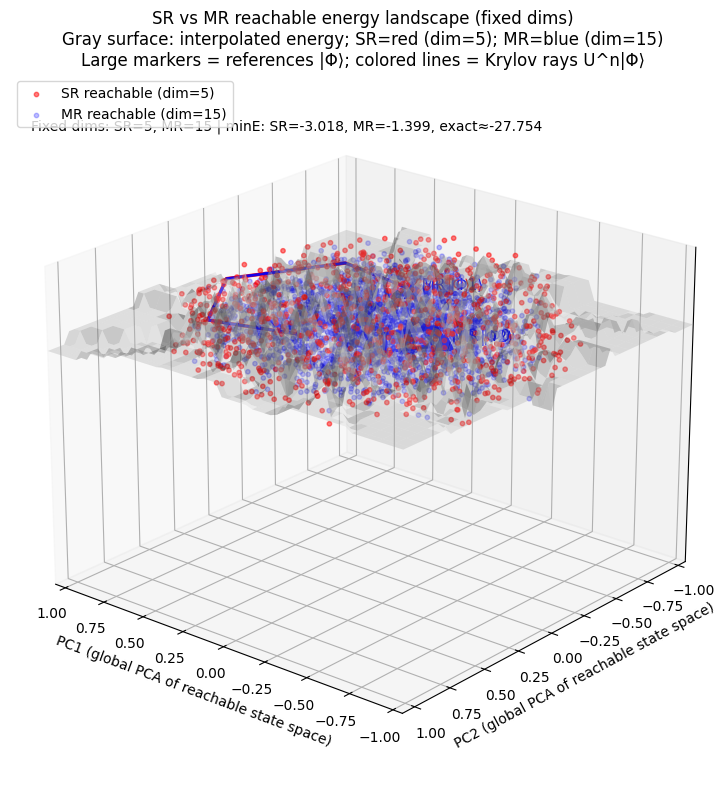

In [9]:
"""
SR vs MR reachable energy landscape (fixed dims: SR=5, MR=15) with:
- ONE shared PCA coordinate system (global mean, no per-batch centering)
- SR scatter = RED, MR scatter = BLUE
- MR reference states = 3 orthogonal single-excitation computational basis states ("000...010..0")
- Reference states are clearly visible (big markers + labels)
- Krylov "rays" shown for each reference: n=0..4 embedded and connected as a polyline
- Gray surface = bounded energy landscape over same PCA domain
- Z ticks hidden (energy axis not visible) but label kept
- Optional: GIF camera rotation (slow)

Dependencies: numpy, scipy, matplotlib
Optional: pillow to save GIF
"""

import numpy as np
import scipy.linalg as la
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================
# 0) Settings
# =========================
n_qubits = 8
JX, JY, JZ = 1.0, 3.0, 2.0

krylov_dim = 5          # SR dim = 5
d_refs = 3              # MR dim = 15
N_sr = krylov_dim
N_mr = d_refs * krylov_dim

# Make MR width obvious
n_samples_sr = 900
n_samples_mr = 2500

# Surface resolution
GRID_N = 60

# Animation (set SAVE_GIF=False if you only want a static plot)
SAVE_GIF = True
FPS = 20
DURATION_S = 10
FRAMES = FPS * DURATION_S
AZIM_SWEEP_DEG = 100      # smaller = slower
ELEV_BASE = 22
ELEV_WOBBLE = 2

SR_COLOR = "red"
MR_COLOR = "blue"
LANDSCAPE_COLOR = "lightgray"

rng = np.random.default_rng(0)

# =========================
# 1) Build Hamiltonian H (dense)
# =========================
I2 = np.array([[1, 0], [0, 1]], dtype=complex)
X2 = np.array([[0, 1], [1, 0]], dtype=complex)
Y2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X2, "Y": Y2, "Z": Z2}

def kron_all(ops):
    M = ops[0]
    for op in ops[1:]:
        M = np.kron(M, op)
    return M

dim = 2 ** n_qubits
H = np.zeros((dim, dim), dtype=complex)
for i in range(n_qubits - 1):
    for p, J in [("X", JX), ("Y", JY), ("Z", JZ)]:
        ops = ["I"] * n_qubits
        ops[i] = p
        ops[i + 1] = p
        H += J * kron_all([PAULI[o] for o in ops])

evals = la.eigvalsh(H)
E_exact = float(evals[0].real)
print("Exact ground energy:", E_exact)

# =========================
# 2) Time evolution U = exp(-i dt H)
# =========================
dt = np.pi / la.norm(H, 2)
U = la.expm(-1j * dt * H)

# =========================
# 3) References and Krylov bases
# =========================
def basis_state_from_bitstring(bs):
    v = np.zeros((dim,), dtype=complex)
    v[int(bs, 2)] = 1.0
    return v

def build_krylov_chain(phi, K):
    chain = [phi]
    cur = phi
    for _ in range(1, K):
        cur = U @ cur
        chain.append(cur)
    return chain

# --- FIXED MR REFERENCES: three orthogonal single-excitation states ("000..010..0")
# Choose three different qubit positions for the "1"
pos = [n_qubits // 2 - 1, n_qubits // 2, n_qubits // 2 + 1]  # centered triple
pos = [p for p in pos if 0 <= p < n_qubits][:d_refs]
while len(pos) < d_refs:
    pos.append(len(pos))  # fallback

def single_excitation_bitstring(n, idx1):
    s = ["0"] * n
    s[idx1] = "1"
    return "".join(s)

mr_ref_bitstrings = [single_excitation_bitstring(n_qubits, p) for p in pos]

# --- SR reference: pick the middle one (matches your single-excitation SR style)
sr_ref_bs = mr_ref_bitstrings[len(mr_ref_bitstrings)//2]

print("SR ref:", sr_ref_bs)
print("MR refs:", mr_ref_bitstrings)
print(f"Dims fixed: SR={N_sr}, MR={N_mr}")

# Build SR basis (dim=5)
phi_sr = basis_state_from_bitstring(sr_ref_bs)
psi_sr = build_krylov_chain(phi_sr, krylov_dim)
B_sr = np.column_stack(psi_sr)  # (dim, 5)

# Build MR basis (dim=15)
phi_refs = [basis_state_from_bitstring(bs) for bs in mr_ref_bitstrings]
psi_mr = []
mr_chains = []  # store chains for rays
for phi in phi_refs:
    chain = build_krylov_chain(phi, krylov_dim)
    mr_chains.append(chain)
    psi_mr.extend(chain)
B_mr = np.column_stack(psi_mr)  # (dim, 15)

# =========================
# 4) Sample reachable states and energies
# =========================
def sample_coeffs(n_samples, N):
    c = rng.normal(size=(n_samples, N)) + 1j * rng.normal(size=(n_samples, N))
    c /= np.linalg.norm(c, axis=1, keepdims=True)
    return c

def states_and_energies(B, n_samples):
    C = sample_coeffs(n_samples, B.shape[1])
    Psi = (B @ C.T).T
    Psi /= np.sqrt(np.sum(np.abs(Psi) ** 2, axis=1, keepdims=True))
    HPsi = (H @ Psi.T).T
    E = np.einsum("bi,bi->b", np.conjugate(Psi), HPsi).real
    return Psi, E

Psi_sr_cloud, E_sr = states_and_energies(B_sr, n_samples_sr)
Psi_mr_cloud, E_mr = states_and_energies(B_mr, n_samples_mr)

def energy_of_state(psi):
    return float(np.vdot(psi, H @ psi).real)

E_phi_sr = energy_of_state(phi_sr)
E_phi_mr = [energy_of_state(phi) for phi in phi_refs]

print("minE SR:", float(E_sr.min()), "minE MR:", float(E_mr.min()))

# =========================
# 5) PCA embedding (GLOBAL mean + fixed PCA basis)
#    Critical fix: NO per-batch centering.
# =========================
# Build training set for PCA: SR+MR clouds + references + all Krylov basis vectors
pca_train = np.vstack([
    Psi_sr_cloud[:min(1200, len(Psi_sr_cloud))],
    Psi_mr_cloud[:min(2000, len(Psi_mr_cloud))],
    phi_sr[None, :],
    np.stack(phi_refs, axis=0),
    np.column_stack(psi_sr).T,
    np.column_stack(psi_mr).T
])

train_r = np.hstack([pca_train.real, pca_train.imag])
mu = train_r.mean(axis=0, keepdims=True)
train_r0 = train_r - mu

_, _, Vt = la.svd(train_r0, full_matrices=False)
PCA2 = Vt[:2].T  # (2*dim, 2)

def embed_pca2_fixed(Psi):
    Z = np.hstack([Psi.real, Psi.imag])
    Z0 = Z - mu
    return Z0 @ PCA2

pc_sr = embed_pca2_fixed(Psi_sr_cloud)
pc_mr = embed_pca2_fixed(Psi_mr_cloud)

pc_phi_sr = embed_pca2_fixed(phi_sr[None, :])[0]
pc_phi_mr = embed_pca2_fixed(np.stack(phi_refs, axis=0))

# Krylov rays
pc_sr_ray = embed_pca2_fixed(np.stack(psi_sr, axis=0))  # (5,2)
pc_mr_rays = [embed_pca2_fixed(np.stack(chain, axis=0)) for chain in mr_chains]  # list of (5,2)

# =========================
# 6) Gray energy surface (bounded and contains both clouds)
# =========================
PC_all = np.vstack([pc_sr, pc_mr, pc_phi_sr[None, :], pc_phi_mr])
E_all = np.concatenate([E_sr, E_mr, np.array([E_phi_sr]), np.array(E_phi_mr)])

pad = 0.06
xmin = PC_all[:, 0].min() - pad * (np.ptp(PC_all[:, 0]) + 1e-12)
xmax = PC_all[:, 0].max() + pad * (np.ptp(PC_all[:, 0]) + 1e-12)
ymin = PC_all[:, 1].min() - pad * (np.ptp(PC_all[:, 1]) + 1e-12)
ymax = PC_all[:, 1].max() + pad * (np.ptp(PC_all[:, 1]) + 1e-12)

gx = np.linspace(xmin, xmax, GRID_N)
gy = np.linspace(ymin, ymax, GRID_N)
GX, GY = np.meshgrid(gx, gy)

GZ = griddata(PC_all, E_all, (GX, GY), method="linear")
mask = np.isnan(GZ)
if np.any(mask):
    GZ[mask] = griddata(PC_all, E_all, (GX, GY), method="nearest")[mask]

z_min = min(E_exact, float(E_all.min())) - 0.5
z_max = float(E_all.max()) + 0.5

# =========================
# 7) Plot (static) + optional GIF rotation
# =========================
fig = plt.figure(figsize=(10.5, 8))
ax = fig.add_subplot(111, projection="3d")

# Landscape
ax.plot_surface(GX, GY, GZ, color=LANDSCAPE_COLOR, alpha=0.30, linewidth=0, antialiased=True)

# Scatters
ax.scatter(pc_sr[:, 0], pc_sr[:, 1], E_sr, s=10, c=SR_COLOR, alpha=0.50, label=f"SR reachable (dim={N_sr})")
ax.scatter(pc_mr[:, 0], pc_mr[:, 1], E_mr, s=10, c=MR_COLOR, alpha=0.25, label=f"MR reachable (dim={N_mr})")

# Reference markers (big, obvious)
ax.scatter([pc_phi_sr[0]], [pc_phi_sr[1]], [E_phi_sr], c=SR_COLOR, s=140, marker="X")
ax.text(pc_phi_sr[0], pc_phi_sr[1], E_phi_sr, "  SR |Φ⟩", color=SR_COLOR, fontsize=11)

for i in range(d_refs):
    ax.scatter([pc_phi_mr[i, 0]], [pc_phi_mr[i, 1]], [E_phi_mr[i]], c=MR_COLOR, s=130, marker="^")
    ax.text(pc_phi_mr[i, 0], pc_phi_mr[i, 1], E_phi_mr[i], f"  MR |Φ{i}⟩", color=MR_COLOR, fontsize=11)

# Krylov rays (this makes “one chain vs three chains” visually clear)
ax.plot(pc_sr_ray[:, 0], pc_sr_ray[:, 1], [energy_of_state(s) for s in psi_sr], color=SR_COLOR, linewidth=2.5, alpha=0.95)
for i, ray in enumerate(pc_mr_rays):
    ax.plot(ray[:, 0], ray[:, 1], [energy_of_state(s) for s in mr_chains[i]], color=MR_COLOR, linewidth=2.0, alpha=0.90)

# Axis labels + title
ax.set_xlabel("PC1 (global PCA of reachable state space)")
ax.set_ylabel("PC2 (global PCA of reachable state space)")
ax.set_zlabel(r"Energy $E=\langle\psi|\hat{H}|\psi\rangle$")   # keep label

# Hide z-axis ticks (energy axis not visible) but keep label
ax.set_zticks([])
ax.zaxis.set_ticklabels([])

ax.set_title(
    "SR vs MR reachable energy landscape (fixed dims)"
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(z_min, z_max)
ax.legend(loc="upper left")

txt = ax.text2D(0.03, 0.92, "", transform=ax.transAxes)
txt.set_text(
    f"Fixed dims: SR=5, MR=15 | minE: SR={float(E_sr.min()):.3f}, MR={float(E_mr.min()):.3f}, exact≈{E_exact:.3f}"
)

plt.tight_layout()

# ---- Optional rotation GIF ----
if SAVE_GIF:
    def update(frame):
        azim = 30 + AZIM_SWEEP_DEG * (frame / (FRAMES - 1))
        elev = ELEV_BASE + ELEV_WOBBLE * np.sin(2 * np.pi * frame / (FRAMES - 1))
        ax.view_init(elev=elev, azim=azim)
        return (ax,)

    ani = FuncAnimation(fig, update, frames=FRAMES, interval=1000 / FPS, blit=False)
    out_gif = "sr_vs_mr_fixeddims_refs_rays.gif"
    try:
        ani.save(out_gif, writer="pillow", fps=FPS)
        print(f"Saved GIF: {out_gif}")
    except Exception as e:
        print("GIF save failed (likely missing pillow). Error:\n", e)
        print("Tip: pip install pillow  (or use MP4 via ffmpeg)")

plt.show()


Saved GIF: sr_vs_mr_rugged_landscape_discovery3.gif


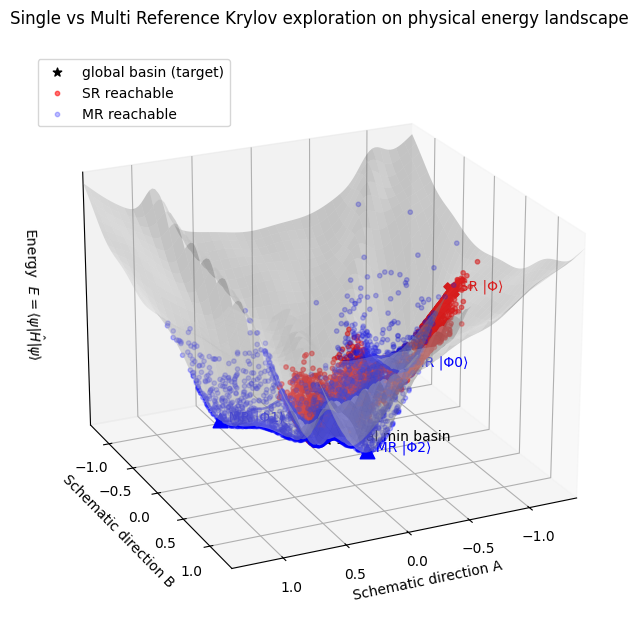

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------------------------
# Controls
# ---------------------------
FPS = 20
DURATION_S = 40
FRAMES = FPS * DURATION_S

SR_COLOR = "red"
MR_COLOR = "blue"
LANDSCAPE_COLOR = "lightgray"

REF_ONLY_SECONDS = 7
REF_ONLY_FRAMES = REF_ONLY_SECONDS * FPS
AZIM_START = 35
AZIM_SWEEP_DEG = 30    # smaller = slower rotation after refs
ELEV_BASE = 22
ELEV_WOBBLE = 2


# SR vs MR reachable geometry knobs
sr_width = 0.07
mr_width = 0.28

# "Discovery" speed: how fast points are revealed
# SR reveals fewer points per frame (harder exploration)
# MR reveals more points per frame (wider coverage)
sr_reveal_frac_end = 1.00
mr_reveal_frac_end = 1.00


rng = np.random.default_rng(2)

# ---------------------------
# Realistic-ish rugged energy landscape
# Think: multiple competing minima + barriers + ruggedness
# ---------------------------
x = np.linspace(-1.4, 1.4, 120)
y = np.linspace(-1.4, 1.4, 120)
X, Y = np.meshgrid(x, y)

def gaussian_well(X, Y, cx, cy, sx, sy, depth):
    return -depth * np.exp(-(((X-cx)/sx)**2 + ((Y-cy)/sy)**2))

def ridge(X, Y, angle, offset, height, width):
    # ridge ~ exp(-((n·[x,y]-offset)^2)/width^2)
    nx, ny = np.cos(angle), np.sin(angle)
    d = nx*X + ny*Y - offset
    return height * np.exp(-(d/width)**2)

def rugged(X, Y):
    # small-scale ripples (like rugged optimization landscape)
    return 0.20*np.sin(6*X+1.3)*np.cos(5*Y-0.7) + 0.10*np.sin(11*X-2)*np.sin(9*Y+0.4)

def E_landscape(X, Y):
    # baseline (keeps energies bounded)
    base = 1.4*(X**2 + 0.9*Y**2)

    # several local minima (competing "configurations")
    wells = (
        gaussian_well(X,Y, -0.9,-0.5, 0.35,0.28, depth=3.2) +   # local basin A
        gaussian_well(X,Y,  0.8,-0.2, 0.30,0.35, depth=2.6) +   # local basin B
        gaussian_well(X,Y,  0.1, 0.9, 0.40,0.25, depth=2.4) +   # local basin C
        gaussian_well(X,Y,  0.0, 0.0, 0.55,0.55, depth=4.2)     # global basin (hard target)
    )

    # barriers/ridges separating basins
    barriers = (
        ridge(X,Y, angle=np.deg2rad(25), offset=0.15, height=1.2, width=0.10) +
        ridge(X,Y, angle=np.deg2rad(-35), offset=-0.05, height=0.9, width=0.12)
    )

    return base + barriers + wells + rugged(X,Y) - 2.0  # shift so some regions are clearly negative

Z = E_landscape(X, Y)

# ---------------------------
# Define SR and MR reachable sets (pedagogical)
# SR: one tube/chain
# MR: multiple tubes + span
# ---------------------------
t = np.linspace(0, 1, 500)

# SR curve: starts away from the global min and gradually approaches it,
# but has trouble crossing ridges (so it "snakes" along one corridor).
sr_curve = np.column_stack([
    -1.1 + 1.25*t,
    -0.1 + 0.25*np.sin(2*np.pi*t) - 0.15*np.sin(5*np.pi*t)
])

# MR refs (3 basins): each starts near a different local minimum
mr_ref_pts = np.array([
    [-0.9, -0.5],   # basin A
    [ 0.8, -0.2],   # basin B
    [ 0.1,  0.9],   # basin C
])

def mr_curve_from_ref(ref, t):
    # each curve heads toward the global basin (0,0) but from a different direction
    target = np.array([0.0, 0.0])
    direction = (target - ref)
    # a bit of curvature (each chain bends differently)
    curve = ref + t[:,None]*direction + 0.12*np.column_stack([np.sin(2*np.pi*t), np.cos(2*np.pi*t)])*(ref[0]-ref[1])
    return curve

mr_curves = [mr_curve_from_ref(r, t) for r in mr_ref_pts]

def sample_tube_progressive(curve, n_points, width, frac):
    # sample only the first "frac" part of the curve (discovery effect)
    max_idx = max(2, int(frac*(len(curve)-1)))
    idx = rng.integers(0, max_idx, size=n_points)
    pts = curve[idx] + rng.normal(scale=width, size=(n_points,2))
    return pts

def E_pts(pts):
    # evaluate landscape at points
    x = pts[:,0]
    y = pts[:,1]
    # nearest-neighbor evaluation on continuous function
    return E_landscape(x, y)

# Pre-generate full clouds so we can reveal them progressively by fraction
N_sr = 2200
N_mr = 3800

# For MR span points: convex combos across different curves -> "wider sheet"
def sample_mr_span(n_points, frac):
    span = []
    max_idx = max(2, int(frac*(len(t)-1)))
    for _ in range(n_points):
        a = rng.random()
        b = rng.random()*(1-a)
        c = 1-a-b
        i = rng.integers(0, max_idx)
        j = rng.integers(0, max_idx)
        k = rng.integers(0, max_idx)
        p = a*mr_curves[0][i] + b*mr_curves[1][j] + c*mr_curves[2][k]
        p += rng.normal(scale=mr_width*0.18, size=2)
        span.append(p)
    return np.array(span)

# ---------------------------
# Figure setup
# ---------------------------
fig = plt.figure(figsize=(10.5, 7.5))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, color=LANDSCAPE_COLOR, alpha=0.28, linewidth=0, antialiased=True)

ax.set_xlabel("Schematic direction A")
ax.set_ylabel("Schematic direction B")
ax.set_zlabel(r"Energy  $E=\langle\psi|\hat{H}|\psi\rangle$")

# Hide z ticks but keep label
ax.set_zticks([])
ax.zaxis.set_ticklabels([])

ax.set_title(
    "Single vs Multi Reference Krylov exploration on physical energy landscape\n"
)

ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_zlim(Z.min()-0.4, Z.max()+0.4)

# Add markers for basins
ax.scatter([0],[0],[E_landscape(0,0)], c="black", s=40, marker="*", label="global basin (target)")
ax.text(0,0,E_landscape(0,0), "  global min basin", color="black")

# SR ref marker (start of SR curve)
sr_ref = sr_curve[0]
ax.scatter([sr_ref[0]],[sr_ref[1]],[E_landscape(sr_ref[0], sr_ref[1])], c=SR_COLOR, s=120, marker="X")
ax.text(sr_ref[0], sr_ref[1], E_landscape(sr_ref[0], sr_ref[1]), "  SR |Φ⟩", color=SR_COLOR)

# MR ref markers
for i,r in enumerate(mr_ref_pts):
    ax.scatter([r[0]],[r[1]],[E_landscape(r[0],r[1])], c=MR_COLOR, s=110, marker="^")
    ax.text(r[0], r[1], E_landscape(r[0],r[1]), f"  MR |Φ{i}⟩", color=MR_COLOR)

# Draw the underlying chains (thin)
ax.plot(sr_curve[:,0], sr_curve[:,1], E_pts(sr_curve), color=SR_COLOR, linewidth=2.0, alpha=0.65)
for c in mr_curves:
    ax.plot(c[:,0], c[:,1], E_pts(c), color=MR_COLOR, linewidth=1.8, alpha=0.55)

# Empty scatters (updated each frame)
sc_sr = ax.scatter([], [], [], s=10, c=SR_COLOR, alpha=0.55, label="SR reachable ")
sc_mr = ax.scatter([], [], [], s=10, c=MR_COLOR, alpha=0.25, label="MR reachable")

ax.legend(loc="upper left")



def frac_schedule(frame):
    # SR reveals more slowly than MR
    u = frame/(FRAMES-1)
    sr_frac = min(1.0, 0.15 + 0.85*u**2.5)
    mr_frac = min(1.0, 0.25 + 0.75*u**1.3)
    return sr_frac, mr_frac

def update(frame):
    # --- phase control ---
    if frame < REF_ONLY_FRAMES:
        # Phase 1: only references, no scatter
        sc_sr._offsets3d = ([], [], [])
        sc_mr._offsets3d = ([], [], [])

        # Camera: keep almost still
        azim = AZIM_START
        elev = ELEV_BASE

    else:
        # Phase 2: discovery starts
        phase_frame = frame - REF_ONLY_FRAMES
        phase_frames = FRAMES - REF_ONLY_FRAMES

        u = phase_frame / max(1, phase_frames - 1)

        # SR reveals slower than MR
        sr_frac = min(1.0, 0.15 + 0.85 * u**1.3)
        mr_frac = min(1.0, 0.25 + 0.75 * u**0.9)

        sr_xy = sample_tube_progressive(
            sr_curve,
            int(N_sr * sr_frac),
            sr_width,
            sr_frac
        )
        sr_E = E_pts(sr_xy)

        mr_xy = np.vstack([
            sample_tube_progressive(mr_curves[0], int((N_mr//4)*mr_frac), mr_width*0.55, mr_frac),
            sample_tube_progressive(mr_curves[1], int((N_mr//4)*mr_frac), mr_width*0.55, mr_frac),
            sample_tube_progressive(mr_curves[2], int((N_mr//4)*mr_frac), mr_width*0.55, mr_frac),
            sample_mr_span(int((N_mr//4)*mr_frac), mr_frac),
        ])
        mr_E = E_pts(mr_xy)

        sc_sr._offsets3d = (sr_xy[:, 0], sr_xy[:, 1], sr_E)
        sc_mr._offsets3d = (mr_xy[:, 0], mr_xy[:, 1], mr_E)

        # Camera: slow rotation only AFTER refs
        azim = AZIM_START + AZIM_SWEEP_DEG * u
        elev = ELEV_BASE + ELEV_WOBBLE * np.sin(2*np.pi * u)

    ax.view_init(elev=elev, azim=azim)
    return (sc_sr, sc_mr)



ani = FuncAnimation(fig, update, frames=FRAMES, interval=1000/FPS, blit=False)

out_gif = "sr_vs_mr_rugged_landscape_discovery3.gif"
try:
    ani.save(out_gif, writer="pillow", fps=FPS)
    print(f"Saved GIF: {out_gif}")
except Exception as e:
    print("GIF save failed (install pillow): pip install pillow")
    print("Error:", e)

plt.show()
